### Tasks:

1. Data Cleaning and Preparation:
● Load the dataset into a data frame or equivalent data structure.
● Handle missing values appropriately (e.g., imputation, deletion).
● Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).
● Detect and treat outliers if necessary.

2. Statistical Summary:
● Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).
● Highlight any interesting findings from this summary.

3. Data Visualization:
● Create histograms or boxplots to visualize the distributions of various numerical variables.
● Use bar charts or pie charts to display the frequency of categories for categorical variables.
● Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
● Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.

4. Pattern Recognition and Insights:
● Identify any correlations between variables and discuss their potential implications.
● Look for trends or patterns over time if temporal data is available.

5. Conclusion:
● Summarize the key insights and patterns discovered through your exploratory analysis.
● Discuss how these findings could impact decision-making or further analyses.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
# Display all columns
pd.set_option("display.max_columns", None)


In [2]:
# Load Dataset
data = pd.read_csv('Cardiotocographic.csv')
data

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [3]:
# Display first 5 rows
data.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [4]:
# Shape of the dataset
data.shape

(2126, 14)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


### Data Cleaning

In [6]:
# Check missing values

print("\n Missing values: ")
data.isnull().sum()


 Missing values: 


LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [7]:
# Fill missing values

numeric_columns = data.select_dtypes(include=np.number).columns

In [8]:
for col in numeric_columns:
    data[col] = data[col].fillna(data[col].mean())

In [9]:
# Check duplicates
print("\n Duplicate Rows:", data.duplicated().sum())


 Duplicate Rows: 2


In [10]:
# Remove duplicates
data.drop_duplicates(inplace=True)

In [11]:
# Check datatypes
print("\n Data Types:")
print(data.dtypes)


 Data Types:
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


### Statistical Summary

In [12]:
print("\n Statistical Summary: ")
print(data.describe())


 Statistical Summary: 
                LB           AC           FM           UC           DL  \
count  2124.000000  2124.000000  2124.000000  2124.000000  2124.000000   
mean    133.342039     0.003220     0.009904     0.004394     0.001897   
std      11.212396     0.004371     0.067571     0.003340     0.003344   
min      51.842487    -0.019284    -0.480634    -0.014925    -0.015393   
25%     126.000000     0.000000     0.000000     0.001858     0.000000   
50%     133.000000     0.001668     0.000000     0.004486     0.000000   
75%     140.000000     0.005612     0.002568     0.006536     0.003292   
max     214.000000     0.038567     0.961268     0.030002     0.030769   

                DS           DP         ASTV         MSTV         ALTV  \
count  2124.000000  2124.000000  2124.000000  2124.000000  2124.000000   
mean      0.000003     0.000175    47.012459     1.364345    10.295650   
std       0.000141     0.000836    18.812403     1.174084    21.212676   
min      -0.0

In [13]:
# Mean
print("\n Mean")
print(data.mean(numeric_only=True))


 Mean
LB          133.342039
AC            0.003220
FM            0.009904
UC            0.004394
DL            0.001897
DS            0.000003
DP            0.000175
ASTV         47.012459
MSTV          1.364345
ALTV         10.295650
MLTV          8.280589
Width        70.460738
Tendency      0.316669
NSP           1.304794
dtype: float64


In [14]:
# Median
print("\n Median")
print(data.median(numeric_only=True))


 Median
LB          133.000000
AC            0.001668
FM            0.000000
UC            0.004486
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.500000
Width        68.000000
Tendency      0.000000
NSP           1.000000
dtype: float64


In [15]:
# Standard Deviation
print("\n Standard Deviation")
print(data.std(numeric_only=True))


 Standard Deviation
LB          11.212396
AC           0.004371
FM           0.067571
UC           0.003340
DL           0.003344
DS           0.000141
DP           0.000836
ASTV        18.812403
MSTV         1.174084
ALTV        21.212676
MLTV         7.736420
Width       42.726905
Tendency     0.642653
NSP          0.641660
dtype: float64


In [16]:
# Interquartile Range(IQR)
Q1 = data.quantile(0.25, numeric_only=True)
Q3 = data.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

print("\n Interquartile Range")
print(IQR)


 Interquartile Range
LB          14.000000
AC           0.005612
FM           0.002568
UC           0.004678
DL           0.003292
DS           0.000000
DP           0.000000
ASTV        29.000000
MSTV         1.000000
ALTV        11.000000
MLTV         6.200000
Width       63.000000
Tendency     1.000000
NSP          0.000000
dtype: float64


### Outlier Detection

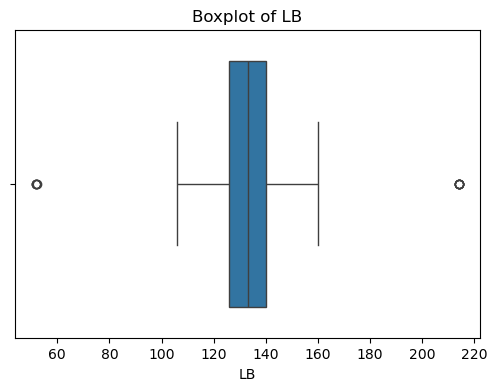

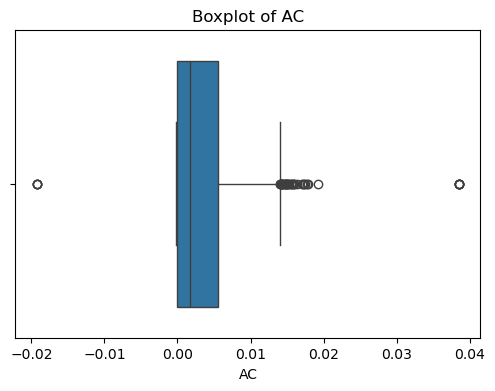

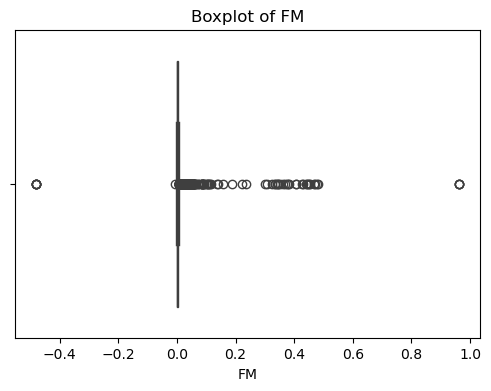

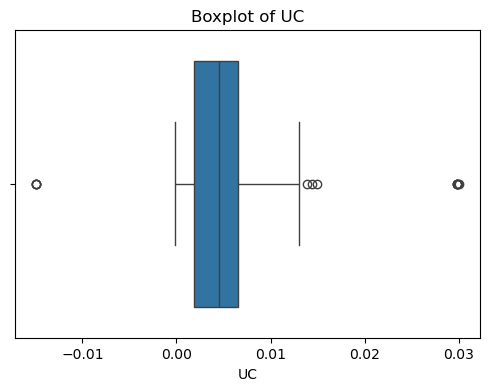

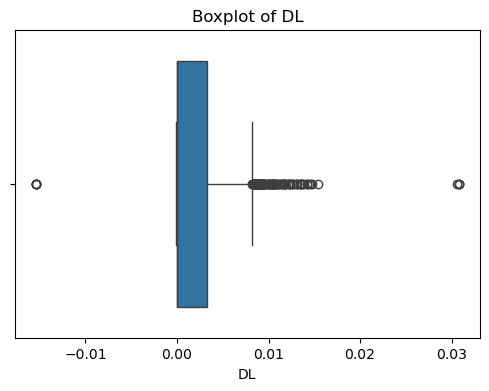

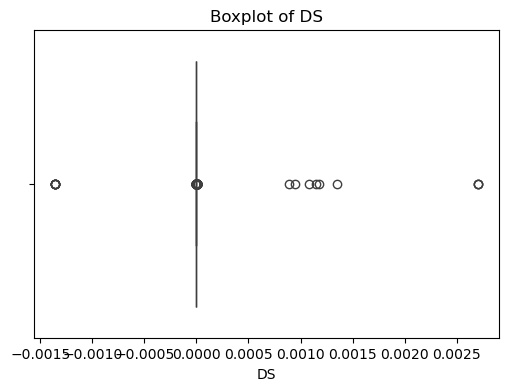

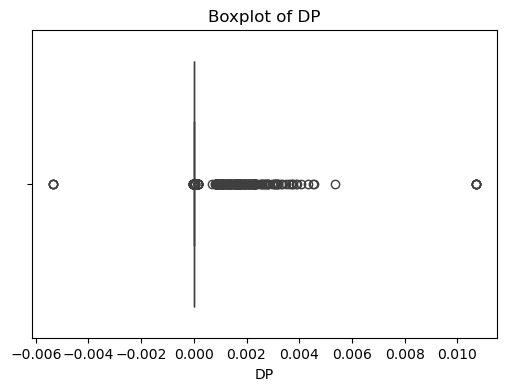

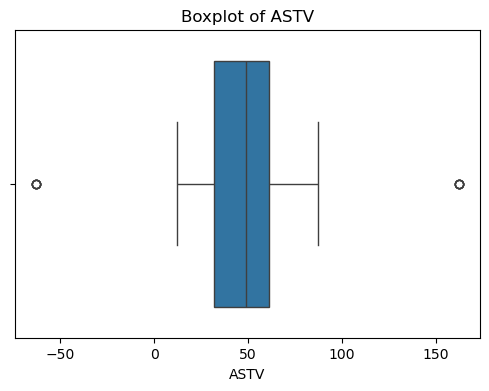

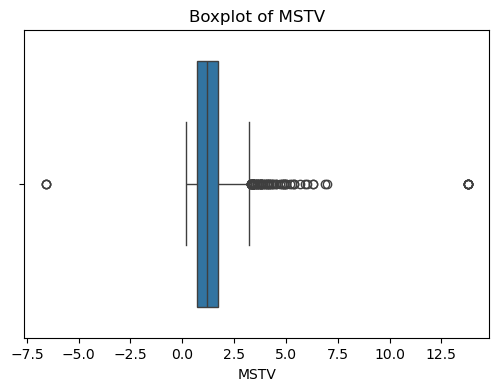

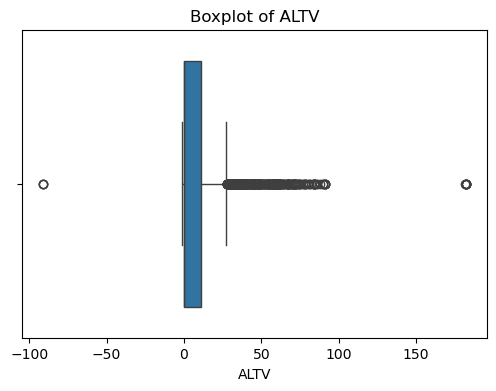

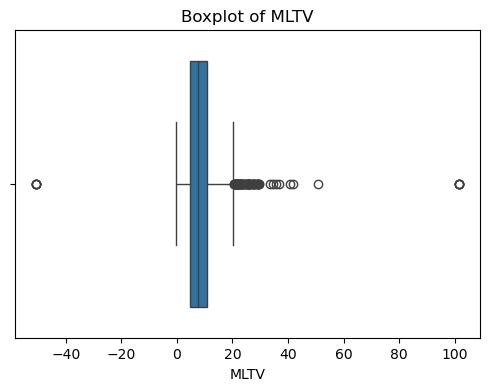

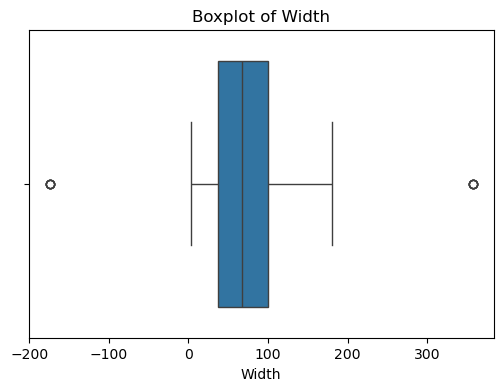

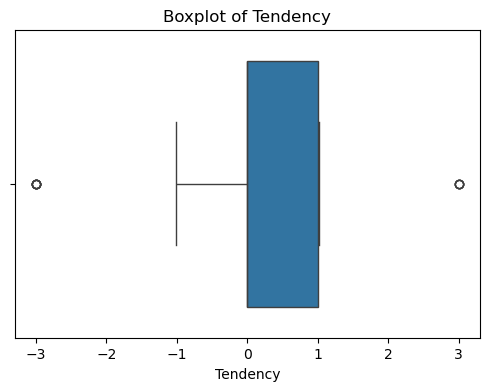

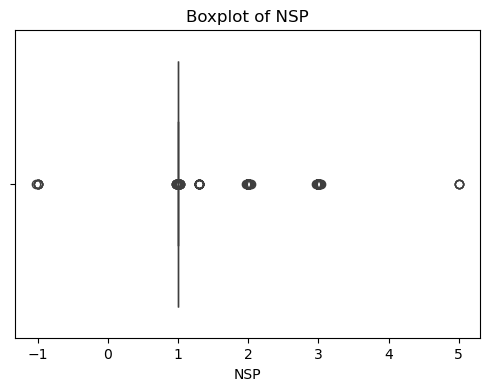

In [17]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Histograms

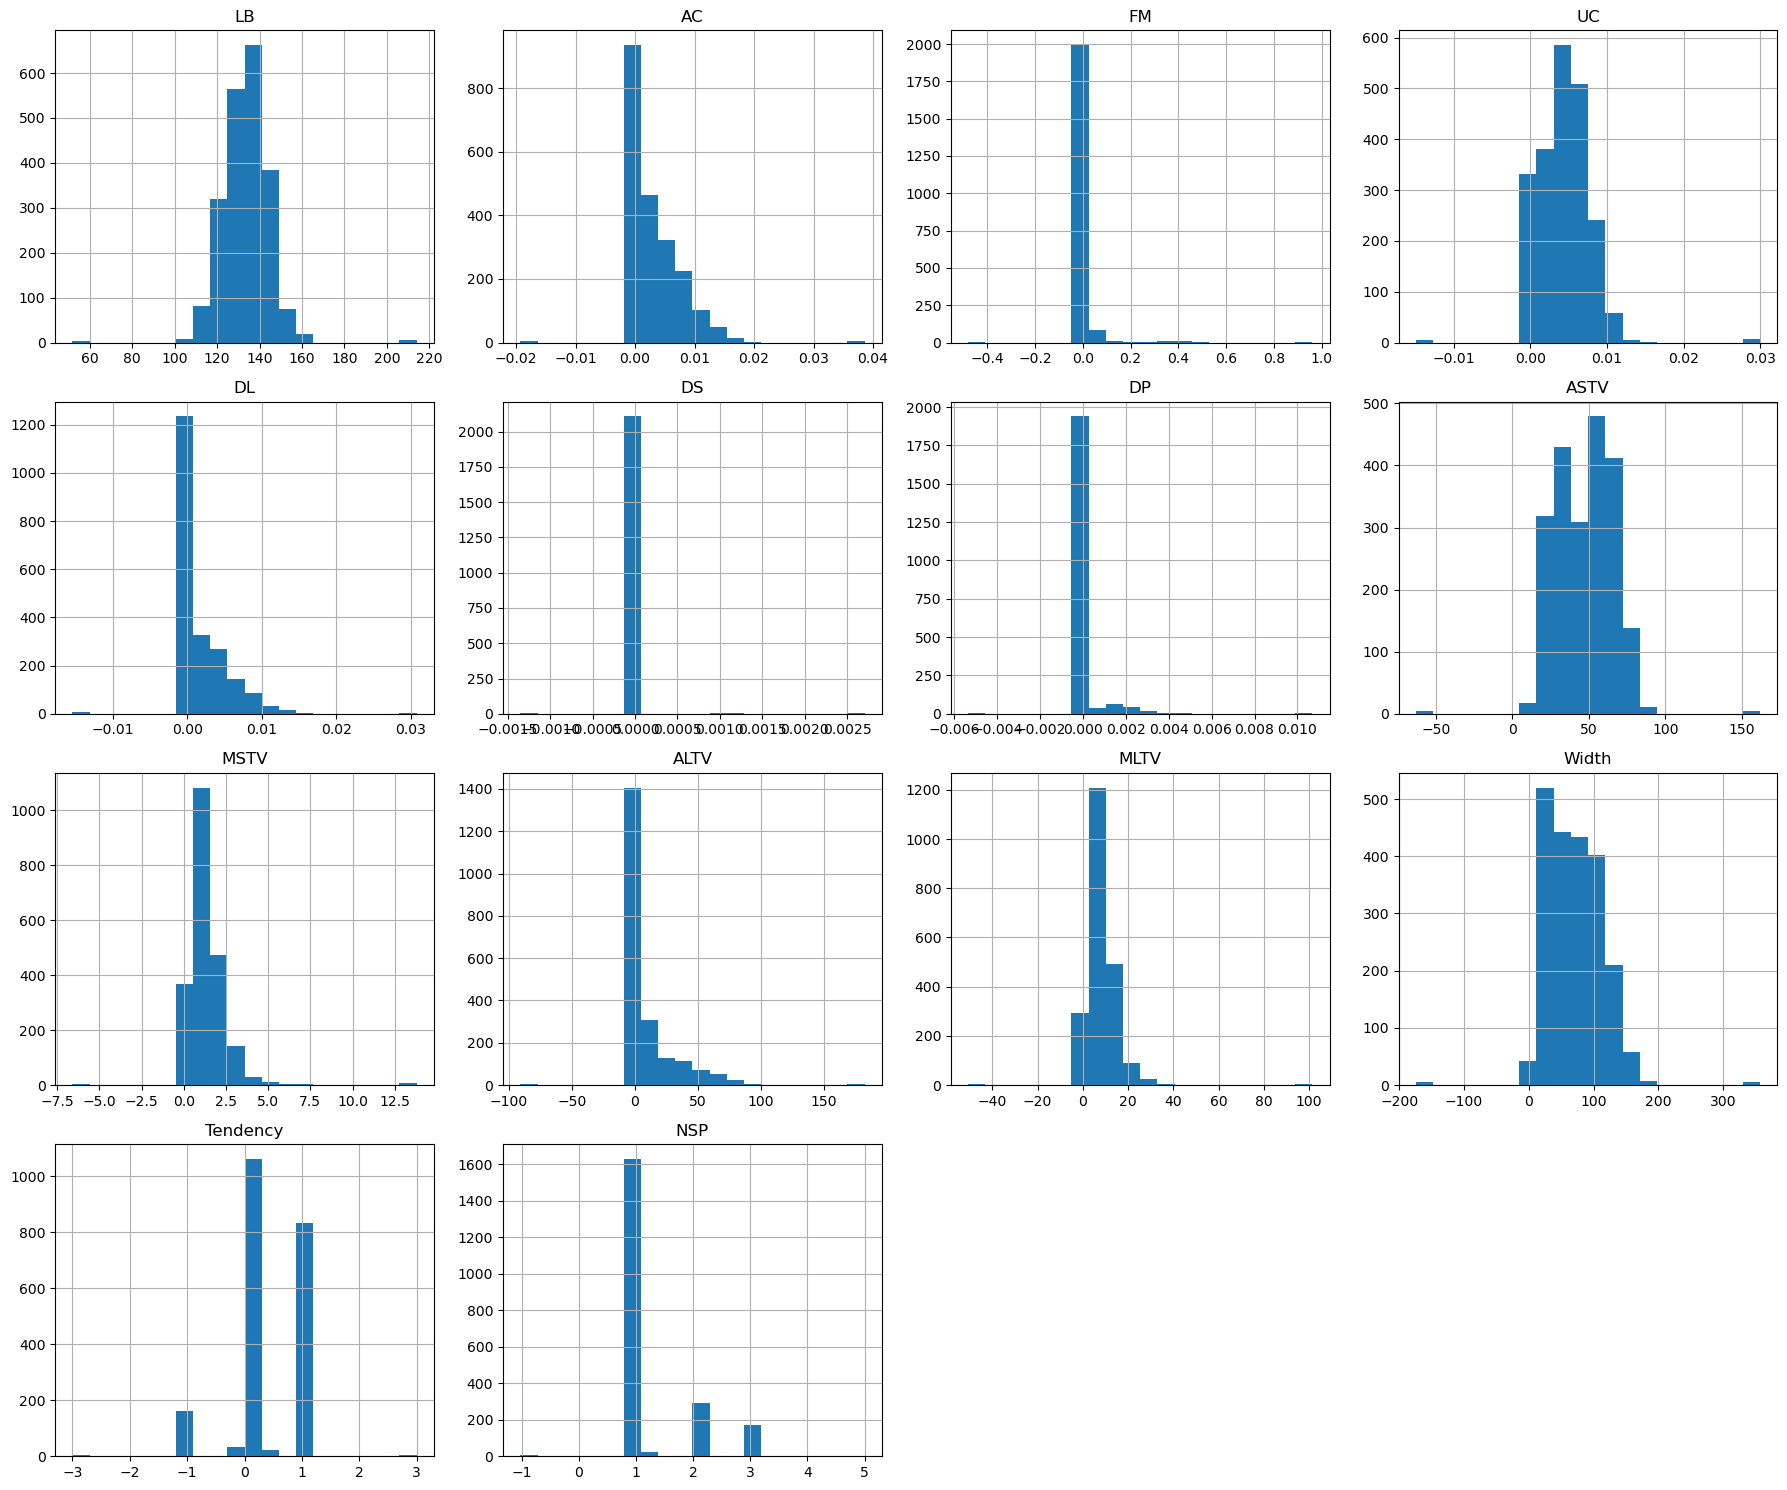

In [18]:
# Histograms

data[numeric_columns].hist(figsize=(18,15), bins=20)
plt.tight_layout()
plt.show()

### Boxplot

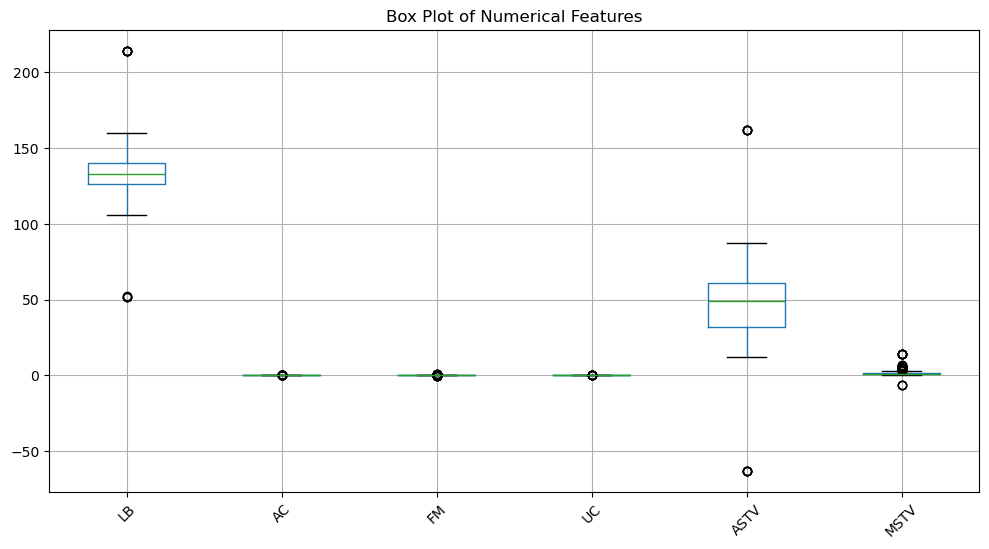

In [19]:

columns = ['LB', 'AC','FM','UC','ASTV','MSTV']
plt.figure(figsize=(12, 6))
data[columns].boxplot()
plt.title("Box Plot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

#### Observation

The boxplot indicates the presence of outliers in several numerical features, particularly LB, ASTV, and MSTV. The ASTV feature exhibits the greatest variability, while AC, FM, and UC are highly concentrated around zero with only a few extreme values. These visualizations help identify the spread of the data and potential outliers that may influence further statistical analysis or machine learning models.

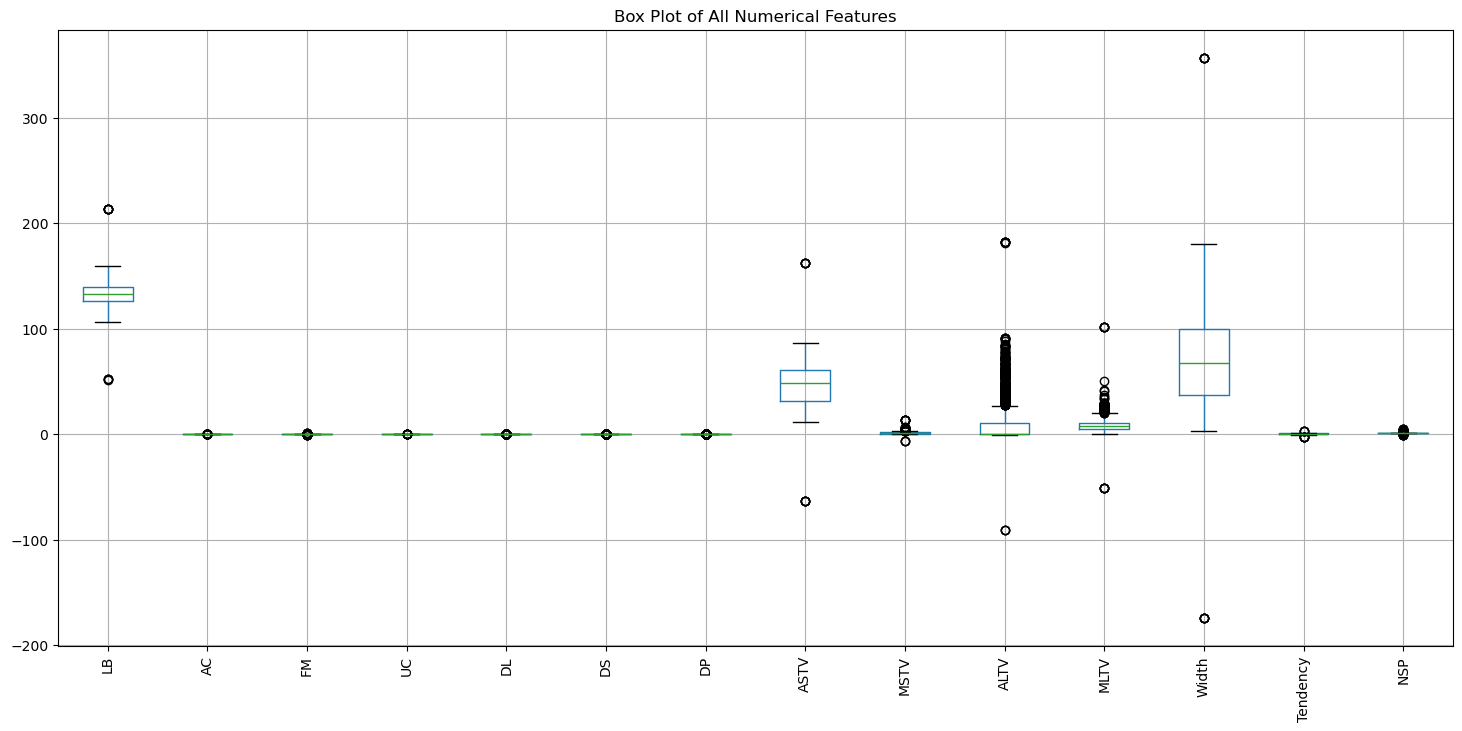

In [20]:
plt.figure(figsize=(18,8))
data.boxplot(rot=90)
plt.title("Box Plot of All Numerical Features")
plt.show()

### Correlation Heatmap

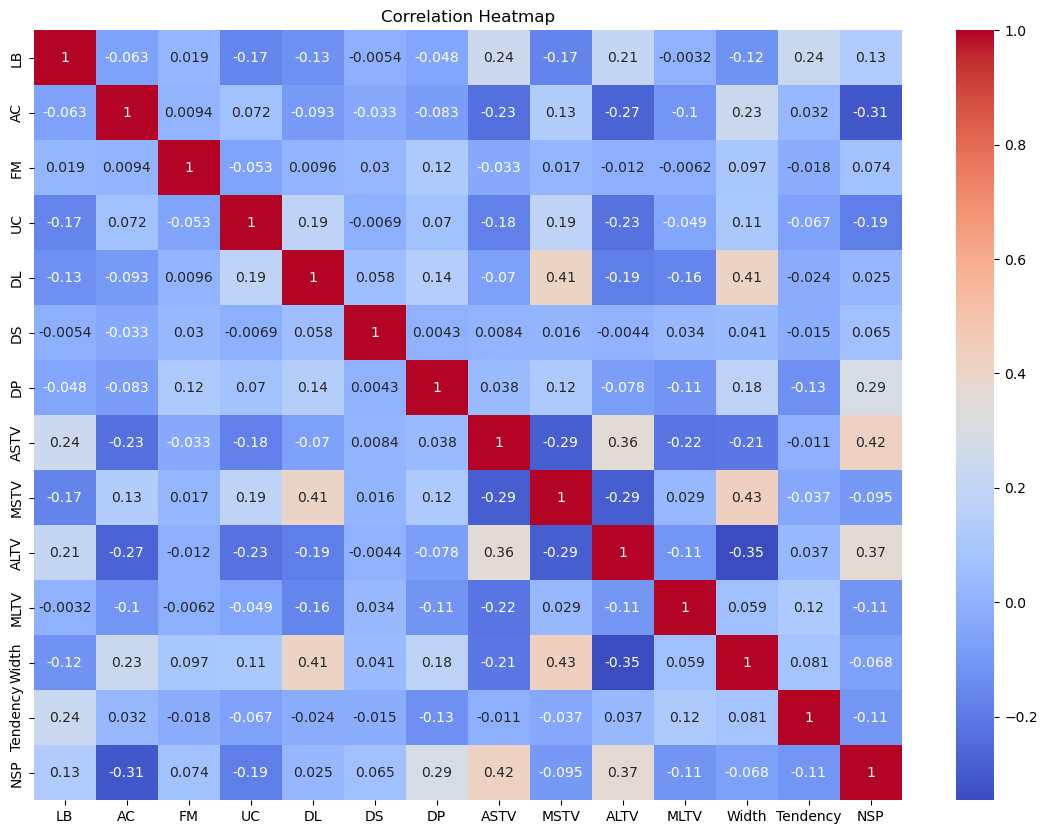

In [21]:
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(numeric_only=True),
           annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Scatter Plot

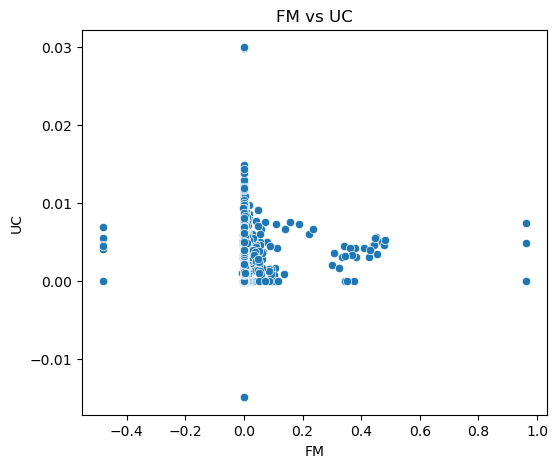

In [22]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=data, 
                x="FM",
               y="UC")
plt.title("FM vs UC")
plt.show()

### Pair Plot

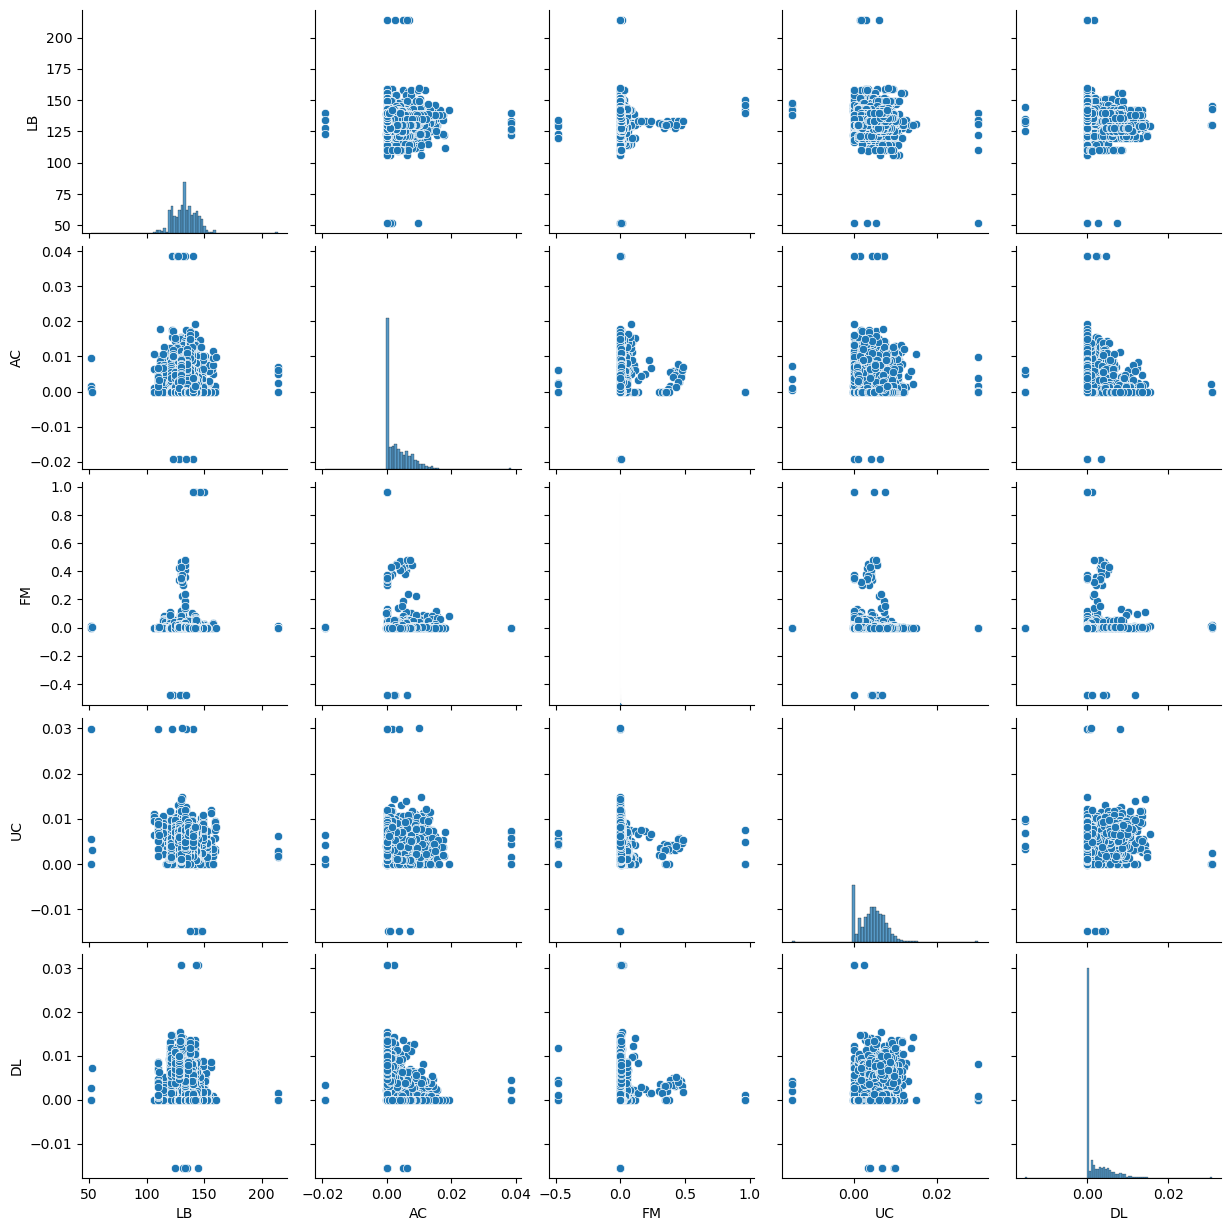

In [23]:
sns.pairplot(data[numeric_columns[:5]])
plt.show()

### Violin Plot

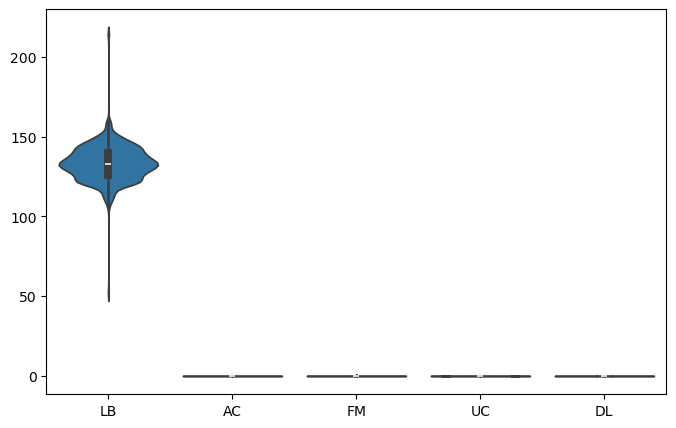

In [24]:
plt.figure(figsize=(8,5))
sns.violinplot(data=data[numeric_columns[:5]])
plt.show()

In [25]:
### Categorical Variable

categorical_columns = data.select_dtypes(include='object').columns

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

#### Observation

The violin plot illustrates the distribution and density of the numerical variables. It highlights the spread, median, and concentration of values, showing that some features have wider distributions and potential outliers compared to others.

In [26]:
### Correlation values

corr = data.corr(numeric_only=True)

print("\n Correlation Matrix")
print(corr)


 Correlation Matrix
                LB        AC        FM        UC        DL        DS  \
LB        1.000000 -0.063451  0.018808 -0.166642 -0.126557 -0.005439   
AC       -0.063451  1.000000  0.009407  0.071551 -0.093330 -0.033109   
FM        0.018808  0.009407  1.000000 -0.053386  0.009641  0.029896   
UC       -0.166642  0.071551 -0.053386  1.000000  0.189737 -0.006942   
DL       -0.126557 -0.093330  0.009641  0.189737  1.000000  0.058429   
DS       -0.005439 -0.033109  0.029896 -0.006942  0.058429  1.000000   
DP       -0.047726 -0.083331  0.121249  0.070348  0.144853  0.004282   
ASTV      0.241666 -0.231059 -0.032838 -0.182379 -0.069907  0.008414   
MSTV     -0.169224  0.133903  0.017061  0.189685  0.410216  0.016079   
ALTV      0.210672 -0.271203 -0.012005 -0.227881 -0.187275 -0.004400   
MLTV     -0.003225 -0.104655 -0.006157 -0.048754 -0.164941  0.034366   
Width    -0.118375  0.234718  0.097125  0.106550  0.408426  0.040831   
Tendency  0.237112  0.031894 -0.018408 -0.0

### Conclusion:
Exploratory Data Analysis (EDA) was performed on the cardiotocography dataset to understand its structure, distribution, and relationships among variables. Data cleaning ensured the dataset was ready for analysis. Statistical summaries provided insights into the central tendency and spread of the variables. Visualizations such as histograms, boxplots, scatter plots, correlation heatmaps, pair plots, and violin plots helped identify distributions, outliers, and correlations. These findings provide a strong foundation for building predictive models for fetal health classification.